RAW DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  o

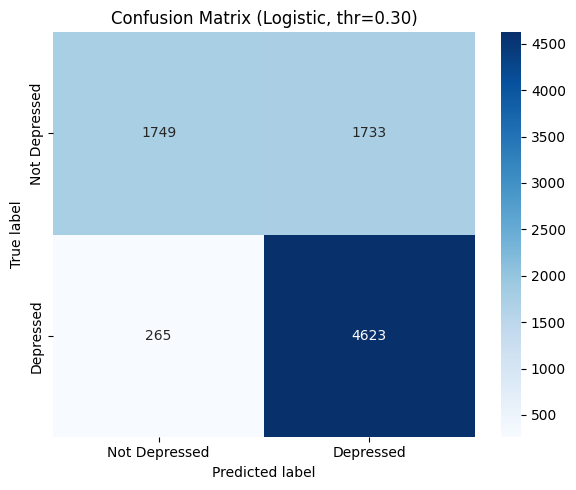

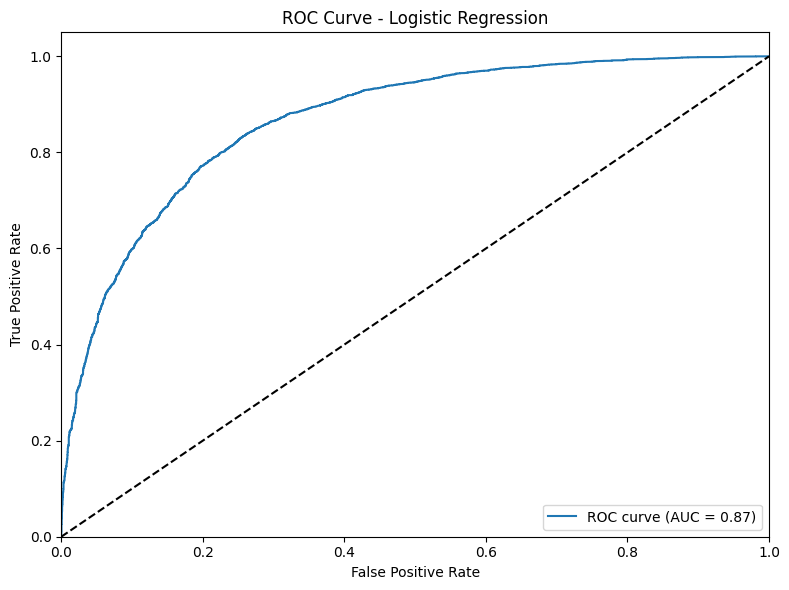


ROC-AUC score (again): 0.867

Best threshold by Youden’s index:
tpr          0.834083
fpr          0.256749
threshold    0.544615
youden_j     0.577334
Name: 1877, dtype: float64

Top 5 thresholds by Youden’s index:
           tpr       fpr  threshold  youden_j
1877  0.834083  0.256749   0.544615  0.577334
1897  0.838584  0.261631   0.536950  0.576953
1862  0.830196  0.253303   0.552011  0.576894
1863  0.830401  0.253590   0.551163  0.576811
1875  0.832651  0.255887   0.546455  0.576764


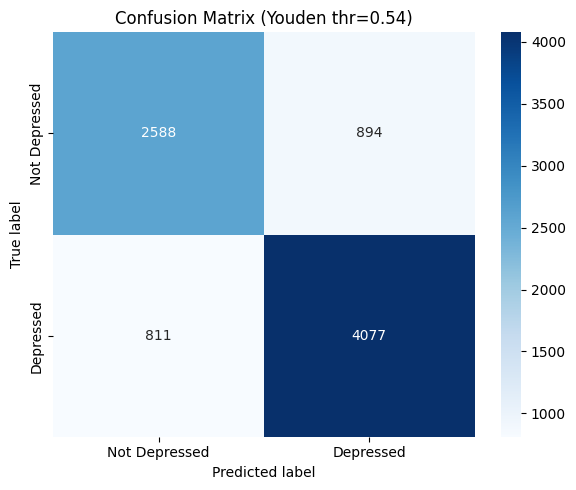


Best threshold by total cost:
threshold       0.2
cost         2781.0
Name: 10, dtype: float64

Top 5 thresholds by cost:
    threshold  cost
10       0.20  2781
11       0.21  2797
9        0.19  2809
13       0.23  2815
12       0.22  2817


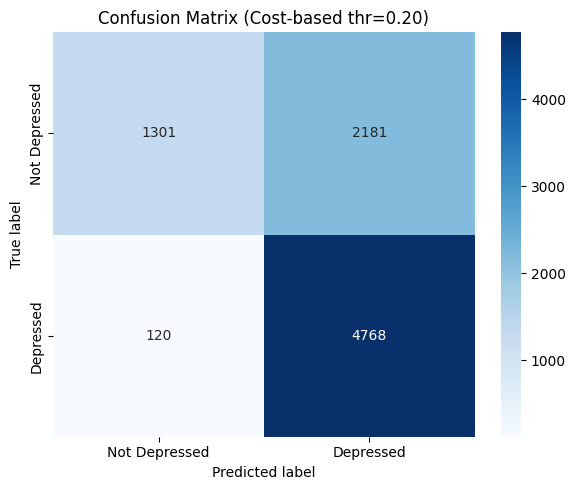


------------------------------------------------------------
Decision Tree Classifier
------------------------------------------------------------

Best CV ROC-AUC (Decision Tree): 0.8362899238290163
Best parameters: {'criterion': 'gini', 'max_depth': 6}

ROC-AUC (Decision Tree, best params): 0.841


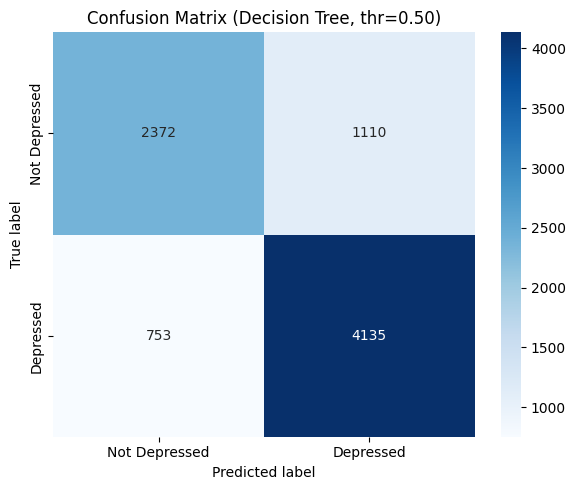

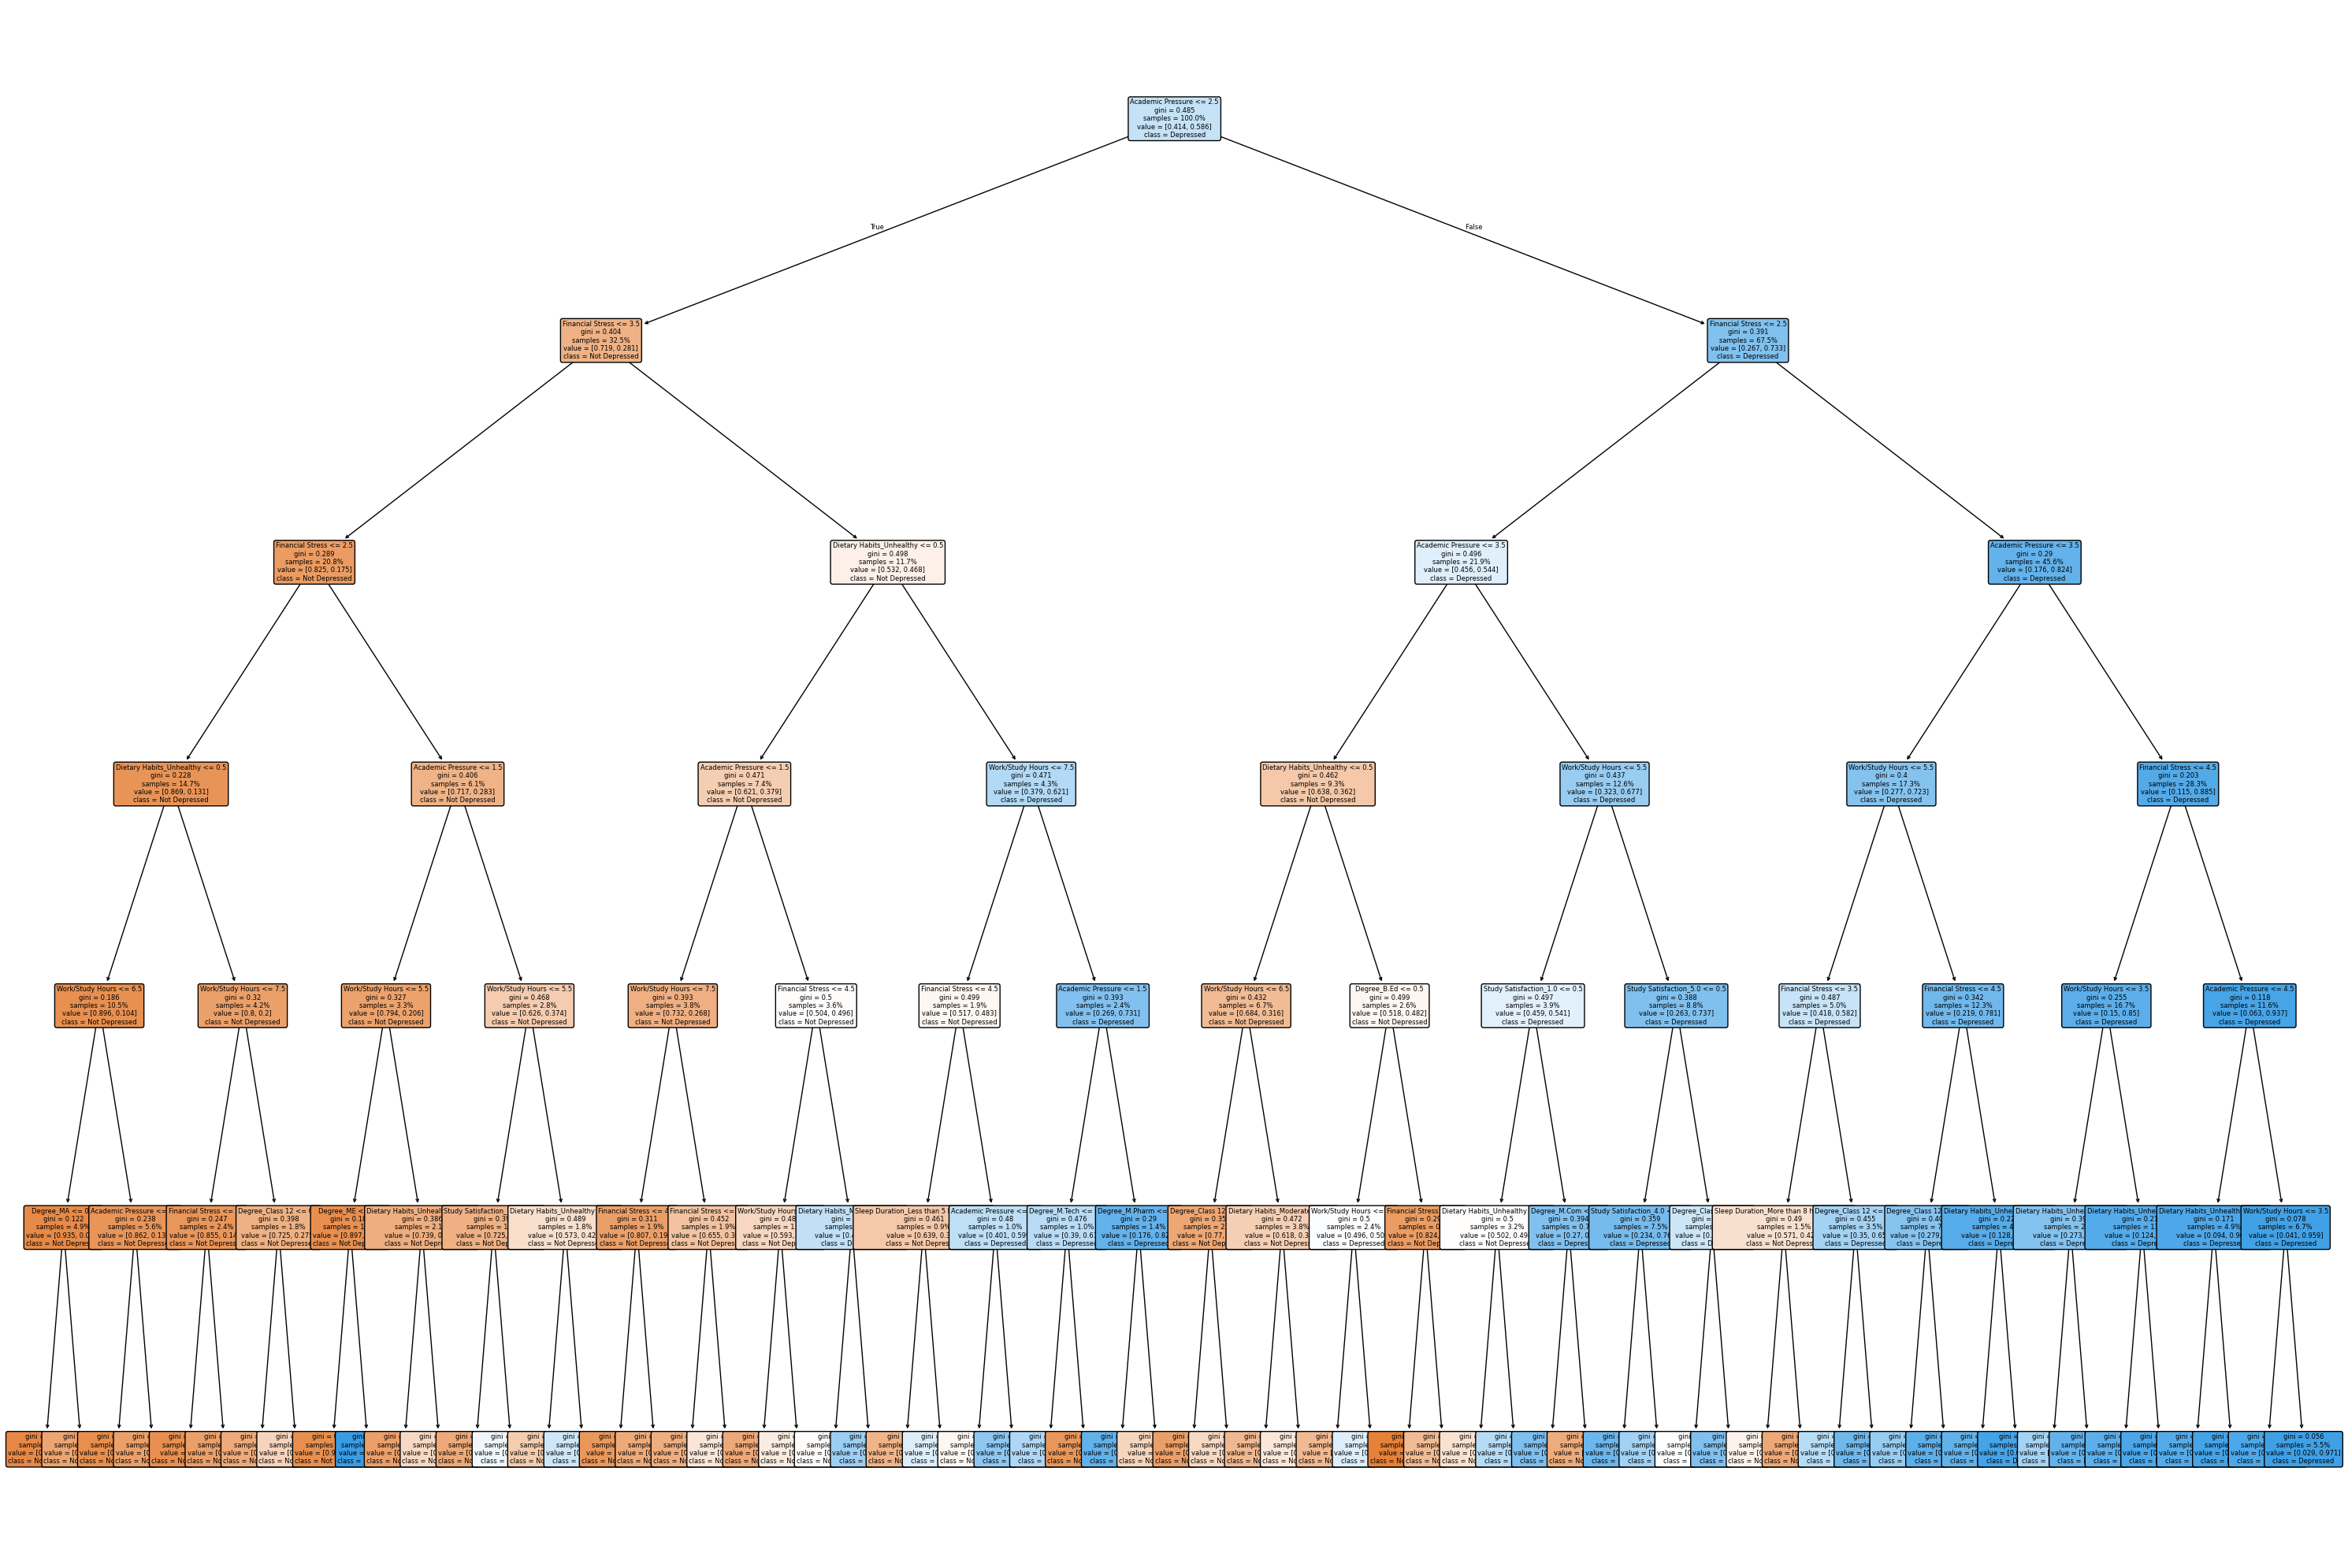


=== CLASSIFICATION SCRIPT COMPLETED SUCCESSFULLY ===


In [6]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# -------------------------------
# 1. VERİYİ YÜKLE
# -------------------------------

# Burayı kendi path'ine göre düzenle:
df_raw = pd.read_csv("/Users/buseozbek/Desktop/hslu 25:26/maldasc/project_datasets/depression_dataset.csv")

print("=" * 60)
print("RAW DATA INFO")
print("=" * 60)
print(df_raw.info())
print()
print(df_raw.head())

# Eksikleri at
df = df_raw.dropna().copy()

# -------------------------------
# 2. CLASSIFICATION: DEPRESSION
# -------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION: DEPRESSION PREDICTION")
print("=" * 60)

y_clf = df["Depression"]

numeric_cols = ["Academic Pressure", "Work/Study Hours", "Financial Stress"]
categorical_cols = [
    "Study Satisfaction",
    "Sleep Duration",
    "Dietary Habits",
    "Degree",
    "Family History of Mental Illness",
]

X_clf_base = df[numeric_cols + categorical_cols]

X_clf = pd.get_dummies(
    X_clf_base,
    columns=categorical_cols,
    drop_first=True
).astype(int)

print("\nClassification feature matrix shape:", X_clf.shape)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42
)

X_train_clf_const = sm.add_constant(X_train_clf, prepend=True)
X_test_clf_const = sm.add_constant(X_test_clf, prepend=True)

# -------------------------------
# 2.1 Logistic Regression (full)
# -------------------------------

logit_full = sm.Logit(y_train_clf, X_train_clf_const)
logit_full_model = logit_full.fit(disp=False)
print("\nLogistic Regression (Full Model) Summary:")
print(logit_full_model.summary2())

# -------------------------------
# 2.2 p-value based feature selection
# -------------------------------

X_fs = X_train_clf_const.copy()
y_fs = y_train_clf.copy()

model_fs = sm.Logit(y_fs, X_fs).fit(disp=False)

while True:
    pvals = model_fs.pvalues.drop("const", errors="ignore")
    worst_p = pvals.max()
    if worst_p <= 0.05:
        break
    worst_var = pvals.idxmax()
    print(f"Dropping {worst_var} (p = {worst_p:.3f})")
    X_fs = X_fs.drop(columns=[worst_var])
    model_fs = sm.Logit(y_fs, X_fs).fit(disp=False)

print("\nFinal Logistic Model after p-value selection:")
print(model_fs.summary2())

final_clf_cols = X_fs.columns.tolist()
print("\nFinal classification feature columns:")
print(final_clf_cols)

X_test_fs = X_test_clf_const[final_clf_cols]

# -------------------------------
# 2.3 Tahminler & ROC-AUC
# -------------------------------

y_prob_test = model_fs.predict(X_test_fs)
auc_full = roc_auc_score(y_test_clf, y_prob_test)
print(f"\nROC-AUC (Logistic, final model): {auc_full:.3f}")

y_pred_df = pd.DataFrame(
    {
        "actual": y_test_clf.values,
        "predicted_prob": y_prob_test.values,
    }
)

print("\nSample of actual vs predicted probabilities:")
print(y_pred_df.sample(10, random_state=42))

# -------------------------------
# 2.4 Confusion Matrix çizme fonksiyonu
# -------------------------------

def draw_cm(actual, predicted, labels=None, title=None):
    cm = confusion_matrix(actual, predicted)
    if labels is None:
        labels = ["0", "1"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

# -------------------------------
# 2.5 Sabit threshold örneği (0.30)
# -------------------------------

threshold_fixed = 0.30
y_pred_df["pred_fixed"] = (y_pred_df["predicted_prob"] >= threshold_fixed).astype(int)

print("\nSample with fixed-threshold predictions (thr = 0.30):")
print(y_pred_df.sample(10, random_state=42))

draw_cm(
    actual=y_pred_df["actual"],
    predicted=y_pred_df["pred_fixed"],
    labels=["Not Depressed", "Depressed"],
    title=f"Confusion Matrix (Logistic, thr={threshold_fixed:.2f})",
)

# -------------------------------
# 2.6 ROC Curve
# -------------------------------

fpr, tpr, roc_thresholds = roc_curve(
    y_pred_df["actual"],
    y_pred_df["predicted_prob"]
)
auc_score = roc_auc_score(
    y_pred_df["actual"],
    y_pred_df["predicted_prob"]
)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\nROC-AUC score (again):", round(auc_score, 3))

# -------------------------------
# 2.7 Youden's index ile en iyi threshold
# -------------------------------

youden_df = pd.DataFrame(
    {"tpr": tpr, "fpr": fpr, "threshold": roc_thresholds}
)
youden_df["youden_j"] = youden_df["tpr"] - youden_df["fpr"]

best_youden = youden_df.sort_values("youden_j", ascending=False).iloc[0]
print("\nBest threshold by Youden’s index:")
print(best_youden)

print("\nTop 5 thresholds by Youden’s index:")
print(youden_df.sort_values("youden_j", ascending=False).head(5))

best_thresh_youden = best_youden["threshold"]

y_pred_df["pred_youden"] = (
    y_pred_df["predicted_prob"] >= best_thresh_youden
).astype(int)

draw_cm(
    actual=y_pred_df["actual"],
    predicted=y_pred_df["pred_youden"],
    labels=["Not Depressed", "Depressed"],
    title=f"Confusion Matrix (Youden thr={best_thresh_youden:.2f})",
)

# -------------------------------
# 2.8 Cost-based threshold
# -------------------------------

def get_total_cost(y_true, probs, threshold, cost_fn, cost_fp):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return fn * cost_fn + fp * cost_fp

COST_FN = 5  # depresyonu kaçırmanın maliyeti
COST_FP = 1  # yanlış pozitif maliyeti

rows_cost = []
for thr in np.linspace(0.1, 0.9, 81):
    cost = get_total_cost(
        y_true=y_pred_df["actual"],
        probs=y_pred_df["predicted_prob"],
        threshold=thr,
        cost_fn=COST_FN,
        cost_fp=COST_FP,
    )
    rows_cost.append({"threshold": thr, "cost": cost})

cost_df = pd.DataFrame(rows_cost)
best_cost_row = cost_df.loc[cost_df["cost"].idxmin()]

print("\nBest threshold by total cost:")
print(best_cost_row)

print("\nTop 5 thresholds by cost:")
print(cost_df.nsmallest(5, "cost"))

best_thresh_cost = best_cost_row["threshold"]

y_pred_df["pred_cost"] = (
    y_pred_df["predicted_prob"] >= best_thresh_cost
).astype(int)

draw_cm(
    actual=y_pred_df["actual"],
    predicted=y_pred_df["pred_cost"],
    labels=["Not Depressed", "Depressed"],
    title=f"Confusion Matrix (Cost-based thr={best_thresh_cost:.2f})",
)

# -------------------------------
# 2.9 Decision Tree + GridSearch
# -------------------------------

print("\n" + "-" * 60)
print("Decision Tree Classifier")
print("-" * 60)

tuned_parameters = [
    {"criterion": ["gini", "entropy"], "max_depth": range(2, 10)}
]

dt_base = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(
    dt_base,
    tuned_parameters,
    cv=10,
    scoring="roc_auc",
)
dt_grid.fit(X_train_clf, y_train_clf)

print("\nBest CV ROC-AUC (Decision Tree):", dt_grid.best_score_)
print("Best parameters:", dt_grid.best_params_)

best_params = dt_grid.best_params_
dt_best = DecisionTreeClassifier(
    criterion=best_params["criterion"],
    max_depth=best_params["max_depth"],
    random_state=42,
)
dt_best.fit(X_train_clf, y_train_clf)

tree_probs_test = dt_best.predict_proba(X_test_clf)[:, 1]
tree_auc = roc_auc_score(y_test_clf, tree_probs_test)
print(f"\nROC-AUC (Decision Tree, best params): {tree_auc:.3f}")

tree_pred_05 = (tree_probs_test >= 0.5).astype(int)
draw_cm(
    actual=y_test_clf,
    predicted=tree_pred_05,
    labels=["Not Depressed", "Depressed"],
    title="Confusion Matrix (Decision Tree, thr=0.50)",
)

plt.figure(figsize=(30, 20))
_ = tree.plot_tree(
    dt_best,
    filled=True,
    feature_names=X_train_clf.columns.tolist(),
    class_names=["Not Depressed", "Depressed"],
    rounded=True,
    proportion=True,
    fontsize=6,
)
plt.tight_layout()
plt.show()

print("\n=== CLASSIFICATION SCRIPT COMPLETED SUCCESSFULLY ===")


In [7]:
import ipywidgets as widgets
from IPython.display import display, Markdown, HTML

# Kategorik seçenekleri datasetten çekelim
sleep_options = sorted(df["Sleep Duration"].unique())
study_sat_options = sorted(df["Study Satisfaction"].unique())
degree_options = sorted(df["Degree"].unique())
diet_options = sorted(df["Dietary Habits"].unique())
fh_options = sorted(df["Family History of Mental Illness"].unique())

# Ortak style/layout → label’lar kesilmesin
common_style = {'description_width': '150px'}  # label için alan
slider_layout = widgets.Layout(width='350px')  # slider genişliği
dropdown_layout = widgets.Layout(width='300px')

ap_min, ap_max = int(df["Academic Pressure"].min()), int(df["Academic Pressure"].max())
fs_min, fs_max = int(df["Financial Stress"].min()), int(df["Financial Stress"].max())
wh_min, wh_max = int(df["Work/Study Hours"].min()), int(df["Work/Study Hours"].max())

academic_pressure_w = widgets.IntSlider(
    description="Academic Pressure",
    min=ap_min, max=ap_max, value=int(df["Academic Pressure"].median()),
    continuous_update=False,
    style=common_style,
    layout=slider_layout
)

work_hours_w = widgets.IntSlider(
    description="Work/Study Hours",
    min=wh_min, max=wh_max, value=int(df["Work/Study Hours"].median()),
    continuous_update=False,
    style=common_style,
    layout=slider_layout
)

financial_stress_w = widgets.IntSlider(
    description="Financial Stress",
    min=fs_min, max=fs_max, value=int(df["Financial Stress"].median()),
    continuous_update=False,
    style=common_style,
    layout=slider_layout
)

study_sat_w = widgets.Dropdown(
    description="Study Satisfaction",
    options=study_sat_options,
    value=study_sat_options[0],
    style=common_style,
    layout=dropdown_layout
)

sleep_w = widgets.Dropdown(
    description="Sleep Duration",
    options=sleep_options,
    value=sleep_options[0],
    style=common_style,
    layout=dropdown_layout
)

diet_w = widgets.Dropdown(
    description="Dietary Habits",
    options=diet_options,
    value=diet_options[0],
    style=common_style,
    layout=dropdown_layout
)

degree_w = widgets.Dropdown(
    description="Degree",
    options=degree_options,
    value=degree_options[0],
    style=common_style,
    layout=dropdown_layout
)

fh_w = widgets.Dropdown(
    description="Family History",
    options=fh_options,
    value=fh_options[0],
    style=common_style,
    layout=dropdown_layout
)


# --- 2) Model'e input hazırlama fonksiyonu ---

def predict_risk_from_widgets():
    """
    Widget'lardan değerleri al, 1 satırlık input DF oluştur,
    final_clf_cols (modelin beklediği kolonlar) ile birebir aynı
    exog matrisi kur, sonra model_fs ile tahmin et.
    """
    # 1) Slider + dropdown değerlerini oku
    user_dict = {
        "Academic Pressure": academic_pressure_w.value,
        "Work/Study Hours": work_hours_w.value,
        "Financial Stress": financial_stress_w.value,
        "Study Satisfaction": study_sat_w.value,
        "Sleep Duration": sleep_w.value,
        "Dietary Habits": diet_w.value,
        "Degree": degree_w.value,
        "Family History of Mental Illness": fh_w.value,
    }

    user_df = pd.DataFrame(user_dict, index=[0])

    # 2) Kategorik değişkenler için get_dummies
    X_input_dum = pd.get_dummies(
        user_df,
        columns=categorical_cols,
        drop_first=True
    ).astype(int)

    # 3) Modelin beklediği kolonları (final_clf_cols) baz alarak exog template yarat
    #    Tüm kolonlar ilk başta 0 olsun
    exog = pd.DataFrame(columns=final_clf_cols)
    exog.loc[0] = 0

    # 4) 'const' kolonu varsa 1 yap (intercept)
    if "const" in exog.columns:
        exog.loc[0, "const"] = 1

    # 5) Dummies'ten gelen kolonları exog içine kopyala
    for col in X_input_dum.columns:
        if col in exog.columns:
            exog.loc[0, col] = X_input_dum.loc[0, col]

    # 6) Artık exog, model_fs'in beklediği ile birebir uyumlu
    prob = float(model_fs.predict(exog)[0])

    return prob, user_df


# --- 3) Rule-based tavsiye fonksiyonu ---

def generate_advice(prob, user_df):
    advice_list = []

    if prob >= 0.7:
        risk_level = "High"
    elif prob >= 0.4:
        risk_level = "Moderate"
    else:
        risk_level = "Low"

    # Sleep Duration string'ine göre basit kontrol
    sleep_choice = str(user_df.loc[0, "Sleep Duration"]).lower()
    if any(x in sleep_choice for x in ["less", "<", "4", "5", "6"]):
        advice_list.append("• Try to increase your sleep duration above 7 hours if possible.")

    if user_df.loc[0, "Academic Pressure"] >= 4:
        advice_list.append("• Consider seeking academic counselling about workload and expectations.")

    if user_df.loc[0, "Financial Stress"] >= 4:
        advice_list.append("• If financial stress is high, explore scholarships or student support options.")

    ss = str(user_df.loc[0, "Study Satisfaction"]).lower()
    if any(x in ss for x in ["low", "dissatisfied", "very low"]):
        advice_list.append("• Reflect on which aspects of your studies are draining and what could be adjusted.")

    if not advice_list:
        advice_list.append("• Keep monitoring your stress and mood, and reach out early if you feel worse.")

    return risk_level, advice_list


# --- 4) Button callback ---

def on_predict_clicked(b):
    with output_box:
        output_box.clear_output()
        prob, user_df = predict_risk_from_widgets()
        risk_percent = round(prob * 100, 1)
        risk_level, advice_list = generate_advice(prob, user_df)

        display(Markdown(f"### 📊 Estimated depression risk: **{risk_percent}%**  → *{risk_level} risk*"))
        display(Markdown("#### 💡 Suggestions (rule-based, not from the model):"))
        for a in advice_list:
            display(Markdown(a))

        display(Markdown(
            "> ⚠️ This is **not** a diagnosis. If you feel persistently low or overwhelmed, "
            "please contact a mental health professional or your university counselling service."
        ))

predict_button.on_click(on_predict_clicked)


# --- 5) Layout ---

controls_left = widgets.VBox([
    academic_pressure_w,
    work_hours_w,
    financial_stress_w,
])

controls_right = widgets.VBox([
    study_sat_w,
    sleep_w,
    diet_w,
    degree_w,
    fh_w,
])

ui = widgets.HBox([controls_left, controls_right])

display(Markdown("## 🧪 Student Depression Risk Simulator"))
display(Markdown(
    "Adjust the sliders and dropdowns below, then click **Predict Risk** to see the estimated depression risk."
))
display(ui)
display(predict_button)
display(output_box)


## 🧪 Student Depression Risk Simulator

Adjust the sliders and dropdowns below, then click **Predict Risk** to see the estimated depression risk.

Button(button_style='primary', description='Predict Risk', style=ButtonStyle())

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<IPython.core.display.Markdown object>…